<a href="https://colab.research.google.com/github/Izabelladesign/171FinalProj/blob/BasicModel/RefiningModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coral Classification: Data Exploration and Preprocessing
- dataset loading
- class/distribution exploration
- sample image visualization
- preprocessing and generator creation

In [1]:
!pip install -q kagglehub scikit-learn seaborn
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aneeshdighe/corals-classification")

print("Path to dataset files:", path)


100%|██████████| 134M/134M [00:07<00:00, 19.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1


In [2]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SUBSET_SIZE = 3000  # target train size
SEED = 42
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# use downloaded dataset path
dataset = Path("/root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1")

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# resolve actual folder containing Training/Validation/Testing
data_directory = dataset
candidate = dataset / "Bleached Corals and Healthy Corals Classification"
if candidate.exists():
    data_directory = candidate

training = data_directory / "Training"
validation = data_directory / "Validation"
testing = data_directory / "Testing"

if not all(p.exists() for p in [training, validation, testing]):
    raise FileNotFoundError("Could not find Training/Validation/Testing folders at DATASET_ROOT")

print("Train:", training)
print("Valid:", validation)
print("Test:", testing)

Train: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Training
Valid: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Validation
Test: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Testing


In [4]:
# Build a dataframe with two columns:
# - filepath: full path to each image
# - label: class folder name (bleached_corals / healthy_corals)
def make_image_df(root_dir):
    rows = []

    # Find class folders inside root_dir
    class_names = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])

    # Walk through each class folder and collect image paths
    for class_name in class_names:
        class_dir = root_dir / class_name
        for fp in class_dir.iterdir():
            if fp.suffix.lower() in IMAGE_EXTS:
                rows.append((str(fp), class_name))

    # Shuffle so data order is random but reproducible (SEED)
    df = pd.DataFrame(rows, columns=["filepath", "label"])
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


# Take a smaller training subset while preserving class ratio
# (stratified = same healthy/bleached proportion as original)
def take_stratified_subset(df, n_samples):
    if n_samples is None or n_samples >= len(df):
        return df.reset_index(drop=True)

    subset, _ = train_test_split(
        df,
        train_size=n_samples,
        stratify=df["label"],
        random_state=SEED,
    )
    return subset.reset_index(drop=True)


# Convert train/valid/test dataframes into Keras generators
# so the model can read images in batches during training/evaluation
def make_generators(train_df, valid_df, test_df):
    # Keep class order consistent across all splits
    classes = sorted(train_df["label"].unique())

    # Train generator gets augmentation to improve generalization
    train_aug = ImageDataGenerator(
        rescale=1./255,  # normalize pixel values
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
    )

    # Validation/Test generators should NOT augment images
    eval_gen = ImageDataGenerator(rescale=1./255)  # normalize only

    # Training generator: shuffled batches + augmentation
    train_gen = train_aug.flow_from_dataframe(
        train_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=True,
        seed=SEED,
    )

    # Validation generator: no shuffle for stable evaluation
    valid_gen = eval_gen.flow_from_dataframe(
        valid_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=False,
    )

    # Test generator: no shuffle for final metrics/reporting
    test_gen = eval_gen.flow_from_dataframe(
        test_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=False,
    )

    return train_gen, valid_gen, test_gen

# Data Exploration

Image counts by split:
Train: 7384
Valid: 985
Test : 923

Train class counts:
label
bleached_corals    3880
healthy_corals     3504
Name: count, dtype: int64

Validation class counts:
label
healthy_corals     500
bleached_corals    485
Name: count, dtype: int64

Test class counts:
label
bleached_corals    485
healthy_corals     438
Name: count, dtype: int64


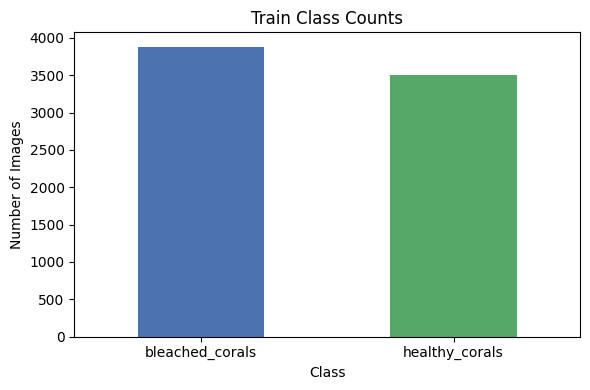

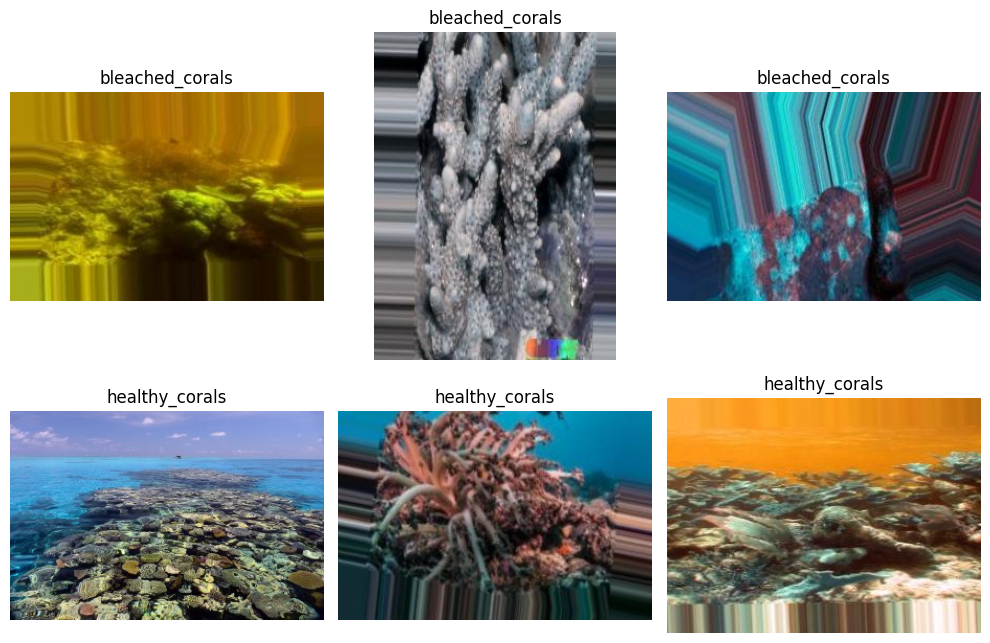

In [5]:
# load full metadata for exploration
train_df_full = make_image_df(training)
valid_df_full = make_image_df(validation)
test_df_full = make_image_df(testing)

print("Image counts by split:")
print(f"Train: {len(train_df_full)}")
print(f"Valid: {len(valid_df_full)}")
print(f"Test : {len(test_df_full)}")

print("\nTrain class counts:")
print(train_df_full["label"].value_counts())

print("\nValidation class counts:")
print(valid_df_full["label"].value_counts())

print("\nTest class counts:")
print(test_df_full["label"].value_counts())

# simple class count plot
train_df_full["label"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4), color=["#4C72B0", "#55A868"])
plt.title("Train Class Counts")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# sample images
sample_rows = train_df_full.sample(n=min(6, len(train_df_full)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
for i, row in sample_rows.iterrows():
    axes[i].imshow(plt.imread(row["filepath"]))
    axes[i].set_title(row["label"])
    axes[i].axis("off")
for j in range(len(sample_rows), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

# Preprocessing

In [6]:
# keep all validation/test images, but use only ~3000 training images
train_df = take_stratified_subset(train_df_full, SUBSET_SIZE)
valid_df = valid_df_full.copy()
test_df = test_df_full.copy()

print(f"Training subset size: {len(train_df)}")
print(train_df["label"].value_counts(normalize=True).rename("train_ratio"))

train_gen, valid_gen, test_gen = make_generators(train_df, valid_df, test_df)

print("\nClass indices:")
print(train_gen.class_indices)

Training subset size: 3000
label
bleached_corals    0.525333
healthy_corals     0.474667
Name: train_ratio, dtype: float64
Found 3000 validated image filenames belonging to 2 classes.
Found 985 validated image filenames belonging to 2 classes.
Found 923 validated image filenames belonging to 2 classes.

Class indices:
{'bleached_corals': 0, 'healthy_corals': 1}


# Coral Classification: Model Training and Evaluation

- custom CNN built from scratch
- VGG19 transfer learning + fine tuning
- evaluation metrics (accuracy, precision, recall, F1)
- model comparison

In [7]:
import seaborn as sns
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,978,529 (99.10 MB)

 Trainable params: 25,978,081 (99.10 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 93s 675ms/step - accuracy: 0.6220 - loss: 3.0108 - val_accuracy: 0.5046 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - accuracy: 0.6633 - loss: 0.6033 - val_accuracy: 0.4924 - val_loss: 8.0768 - learning_rate: 0.0010
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 455ms/step - accuracy: 0.6913 - loss: 0.5920 - val_accuracy: 0.4995 - val_loss: 2.9696 - learning_rate: 0.0010
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7117 - loss: 0.5713
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 470ms/step - accuracy: 0.7147 - loss: 0.5657 - val_accuracy: 0.4893 - val_loss: 4.2121 - learning_rate: 0.0010
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 468ms/step - accuracy: 0.7243 - loss: 0.5440 - val_accuracy: 0.4985 - val_loss: 2.4507 - learning_rate: 5.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 462ms/step - accuracy: 0.7363 - loss: 

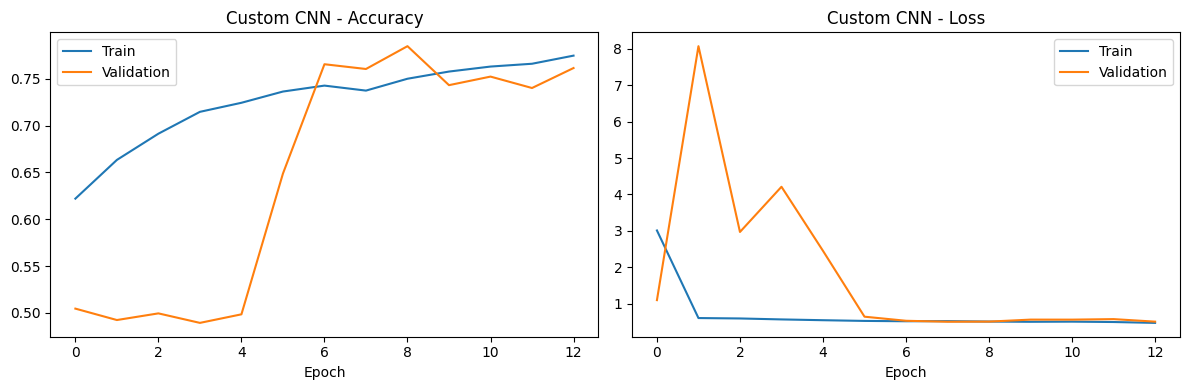

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step
Custom CNN Results:
Accuracy  : 0.7801
Precision : 0.7403
Recall    : 0.8265
F1 Score  : 0.7810
                 precision    recall  f1-score   support

bleached_corals       0.82      0.74      0.78       485
 healthy_corals       0.74      0.83      0.78       438

       accuracy                           0.78       923
      macro avg       0.78      0.78      0.78       923
   weighted avg       0.78      0.78      0.78       923



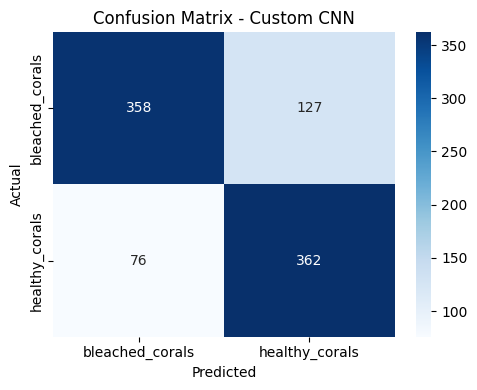

In [8]:
# ── Model 1: Custom CNN ──────────────────────────────────────────────────────
# we build this one from scratch using convolutional layers
# each conv layer learns to detect patterns like edges, colors, and textures
# max pooling reduces the image size after each block to save computation
# dropout randomly disables some neurons during training to avoid overfitting
# the final dense layer outputs a single value between 0 and 1
# 0 = bleached coral, 1 = healthy coral

cnn_model = models.Sequential([
    Input(shape=(224, 224, 3)),

    # block 1 - detect basic things like edges and color
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    # block 2 - detect more complex patterns
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    # block 3 - detect higher level features like coral structure
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    # flatten and classify
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),  # output: probability of being healthy
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# train the CNN
# early stopping will stop training early if val_loss stops improving
# this saves time and prevents overfitting
cnn_history = cnn_model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1,
)

# plot training curves to see how the model improved over time
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history["accuracy"], label="Train")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Custom CNN - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(cnn_history.history["loss"], label="Train")
axes[1].plot(cnn_history.history["val_loss"], label="Validation")
axes[1].set_title("Custom CNN - Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# evaluate on the test set
test_gen.reset()
cnn_preds = (cnn_model.predict(test_gen) > 0.5).astype(int).flatten()
cnn_true  = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Custom CNN Results:")
print(f"Accuracy  : {accuracy_score(cnn_true, cnn_preds):.4f}")
print(f"Precision : {precision_score(cnn_true, cnn_preds):.4f}")
print(f"Recall    : {recall_score(cnn_true, cnn_preds):.4f}")
print(f"F1 Score  : {f1_score(cnn_true, cnn_preds):.4f}")
print(classification_report(cnn_true, cnn_preds, target_names=class_names))

# confusion matrix
cm = confusion_matrix(cnn_true, cnn_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - Custom CNN")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,155,969 (76.89 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 59s 573ms/step - accuracy: 0.5170 - loss: 0.7332 - val_accuracy: 0.6010 - val_loss: 0.6702 - learning_rate: 1.0000e-04
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 55s 583ms/step - accuracy: 0.5683 - loss: 0.6823 - val_accuracy: 0.6325 - val_loss: 0.6511 - learning_rate: 1.0000e-04
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 556ms/step - accuracy: 0.5980 - loss: 0.6668 - val_accuracy: 0.6569 - val_loss: 0.6374 - learning_rate: 1.0000e-04
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 553ms/step - accuracy: 0.6220 - loss: 0.6460 - val_accuracy: 0.6822 - val_loss: 0.6205 - learning_rate: 1.0000e-04
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 557ms/step - accuracy: 0.6497 - loss: 0.6261 - val_accuracy: 0.6629 - val_loss: 0.6178 - learning_rate: 1.0000e-04
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 548ms/step - accuracy: 0.6583 - loss: 0.6143 - val_accuracy: 0.6975 - val_loss: 0.6016 - learning_rate: 1.0000e-04
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 547ms/step - acc

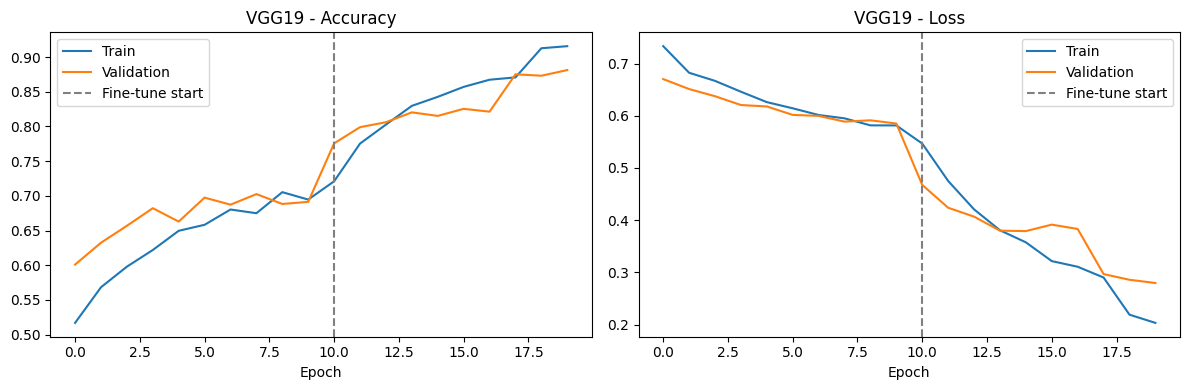

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 628ms/step
VGG19 Results:
Accuracy  : 0.8613
Precision : 0.7914
Recall    : 0.9612
F1 Score  : 0.8680
                 precision    recall  f1-score   support

bleached_corals       0.96      0.77      0.85       485
 healthy_corals       0.79      0.96      0.87       438

       accuracy                           0.86       923
      macro avg       0.87      0.87      0.86       923
   weighted avg       0.88      0.86      0.86       923



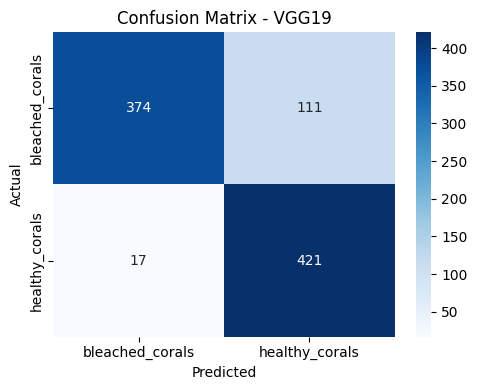

In [10]:
# ── Model 2: VGG19 with Transfer Learning ───────────────────────────────────
# instead of training from scratch, we load VGG19 which was already trained
# on millions of images and already knows how to detect shapes and textures
# we freeze all its layers so the pretrained weights dont change
# then we add our own layers on top to classify healthy vs bleached coral

vgg_base = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False  # freeze all the pretrained layers

vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),  # condense the features into one vector
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

# phase 1: train just the new layers we added on top
vgg_history_1 = vgg_model.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1,
)

# phase 2: unfreeze the last conv block of VGG19 and fine tune it
# we use a very small learning rate so we dont destroy the pretrained weights
for layer in vgg_base.layers:
    if layer.name == "block5_conv1":  # unfreeze from block 5 onwards
        vgg_base.trainable = True
    layer.trainable = vgg_base.trainable

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller lr
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg_history_2 = vgg_model.fit(
    train_gen,
    epochs=10,
    validation_data=valid_gen,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ],
    verbose=1,
)

# combine both phases into one history for plotting
full_acc     = vgg_history_1.history["accuracy"]     + vgg_history_2.history["accuracy"]
full_val_acc = vgg_history_1.history["val_accuracy"] + vgg_history_2.history["val_accuracy"]
full_loss    = vgg_history_1.history["loss"]         + vgg_history_2.history["loss"]
full_val_loss= vgg_history_1.history["val_loss"]     + vgg_history_2.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(full_acc,     label="Train")
axes[0].plot(full_val_acc, label="Validation")
axes[0].axvline(x=len(vgg_history_1.history["accuracy"]), color="gray", linestyle="--", label="Fine-tune start")
axes[0].set_title("VGG19 - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(full_loss,     label="Train")
axes[1].plot(full_val_loss, label="Validation")
axes[1].axvline(x=len(vgg_history_1.history["loss"]), color="gray", linestyle="--", label="Fine-tune start")
axes[1].set_title("VGG19 - Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# evaluate VGG19 on the test set
test_gen.reset()
vgg_preds = (vgg_model.predict(test_gen) > 0.5).astype(int).flatten()
vgg_true  = test_gen.classes

print("VGG19 Results:")
print(f"Accuracy  : {accuracy_score(vgg_true, vgg_preds):.4f}")
print(f"Precision : {precision_score(vgg_true, vgg_preds):.4f}")
print(f"Recall    : {recall_score(vgg_true, vgg_preds):.4f}")
print(f"F1 Score  : {f1_score(vgg_true, vgg_preds):.4f}")
print(classification_report(vgg_true, vgg_preds, target_names=class_names))

cm = confusion_matrix(vgg_true, vgg_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - VGG19")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

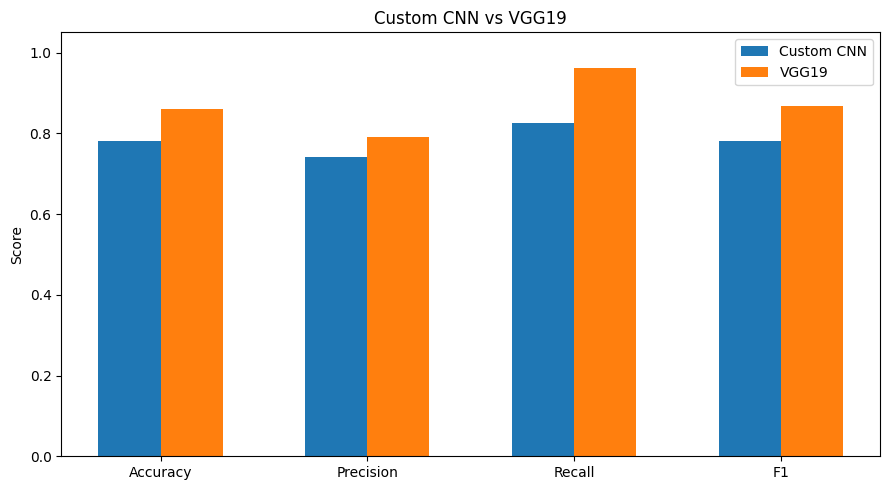

In [11]:
# Final Comparison

metrics = ["Accuracy", "Precision", "Recall", "F1"]
cnn_scores = [
    accuracy_score(cnn_true, cnn_preds),
    precision_score(cnn_true, cnn_preds),
    recall_score(cnn_true, cnn_preds),
    f1_score(cnn_true, cnn_preds),
]
vgg_scores = [
    accuracy_score(vgg_true, vgg_preds),
    precision_score(vgg_true, vgg_preds),
    recall_score(vgg_true, vgg_preds),
    f1_score(vgg_true, vgg_preds),
]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, cnn_scores, width, label="Custom CNN")
ax.bar(x + width/2, vgg_scores, width, label="VGG19")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Custom CNN vs VGG19")
ax.legend()
plt.tight_layout()
plt.show()